# Error Analysis & Visualizations
**RAG-Driven Data Cleaning with PyDI — CS715 Seminar FSS2026**

This notebook:
1. Loads all 6 experimental configurations
2. Builds a side-by-side comparison table (GT once, all predictions as columns)
3. Runs automated error analysis per attribute per config
4. Generates all visualizations for report and presentation

## File Mapping
| File | Experiment |
|---|---|
| `exp8_1_llm_only.csv` | Exp 1 — LLM-only baseline |
| `exp8_1_rag.csv` | Exp 2 — RAG full clean KB |
| `exp9_rag.csv` | Exp 3 — RAG confusing KB |
| `exp10_easy_rag.csv` | Exp 4a — Reranker clean KB |
| `exp10_confusing_rag.csv` | Exp 4b — Reranker confusing KB |
| `exp10_bge_rag.csv` | Exp 5 — BGE + Reranker clean KB |

## 1. Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150,
})

NAVY  = '#0D1B2A'; TEAL  = '#0891B2'; GOLD  = '#F59E0B'
GREEN = '#0D9488'; RED   = '#E11D48'; GREY  = '#64748B'

FIGURES_DIR = 'analysis_figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures → {FIGURES_DIR}/')

Figures → analysis_figures/


## 2. Load All Result Files

Each file is loaded and assigned a short config label.
The `ce_judgment` column is standardised to `judgment` across all files.

In [19]:
NUMERIC_ATTRIBUTES = {'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm'}
TEXT_ATTRIBUTES    = {'bus_type', 'model_number', 'model'}
ATTR_ORDER = ['bus_type', 'model', 'model_number',
              'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']

FILE_MAP = {
    'Exp1: LLM-only':        'exp8_1_llm_only.csv',
    'Exp2: RAG clean':       'exp8_1_rag.csv',
    'Exp4a: +Reranker':      'exp10_easy_rag.csv',
    'Exp5: BGE+RR':          'exp10_bge_rag.csv',
}

CONFIG_ORDER  = list(FILE_MAP.keys())
CONFIG_COLORS = [GREY, TEAL, GOLD, TEAL, GOLD, GREEN]

def load_result(path, label):
    if not os.path.exists(path):
        print(f'  ⚠️  Not found: {path}')
        return None
    df = pd.read_csv(path)
    df['config'] = label
    # Normalise judgment column
    if 'ce_judgment' in df.columns:
        df['judgment'] = df['ce_judgment']
    elif 'llm_judgment' in df.columns:
        df['judgment'] = df['llm_judgment']
    else:
        df['judgment'] = 'unknown'
    print(f'  ✓ {path}: {len(df)} rows, judgment col: {"ce_judgment" if "ce_judgment" in df.columns else "llm_judgment"}')
    return df

print('Loading files...')
dfs = {}
for label, path in FILE_MAP.items():
    df = load_result(path, label)
    if df is not None:
        dfs[label] = df

all_results = pd.concat(list(dfs.values()), ignore_index=True)
available   = [c for c in CONFIG_ORDER if c in dfs]

print(f'\nTotal rows: {len(all_results)}')
print(f'Configs loaded: {available}')

Loading files...
  ✓ exp8_1_llm_only.csv: 51 rows, judgment col: llm_judgment
  ✓ exp8_1_rag.csv: 51 rows, judgment col: llm_judgment
  ✓ exp10_easy_rag.csv: 51 rows, judgment col: ce_judgment
  ✓ exp10_bge_rag.csv: 51 rows, judgment col: ce_judgment

Total rows: 204
Configs loaded: ['Exp1: LLM-only', 'Exp2: RAG clean', 'Exp4a: +Reranker', 'Exp5: BGE+RR']


## 3. Side-by-Side Comparison Table

One row per (df1_idx, attribute). Ground truth appears once.
Each experiment's prediction is a separate column.
Correctness (standard eval) shown as ✓/✗ next to each prediction.

**Saved to:** `side_by_side_comparison.csv` and `side_by_side_comparison.xlsx`

In [20]:
# Build side-by-side — one row per (df1_idx, attribute)
base = dfs[available[0]][['df1_idx', 'attribute', 'ground_truth', 'is_numeric']].copy()

for label in available:
    df_c  = dfs[label][['df1_idx', 'attribute', 'predicted', 'correct_standard', 'judgment']].copy()
    short = label.replace('Exp1: ', '').replace('Exp2: ', '').replace(
            'Exp3: ', '').replace('Exp4a: ', '').replace('Exp4b: ', '').replace('Exp5: ', '')
    df_c  = df_c.rename(columns={
        'predicted':        f'pred_{short}',
        'correct_standard': f'correct_{short}',
        'judgment':         f'judgment_{short}',
    })
    base = base.merge(df_c, on=['df1_idx', 'attribute'], how='left')

# Sort by attribute then row index
base = base.sort_values(['attribute', 'df1_idx']).reset_index(drop=True)

# Add correctness summary column — how many configs got it right
correct_cols = [c for c in base.columns if c.startswith('correct_')]
base['n_correct'] = base[correct_cols].sum(axis=1)
base['n_configs']  = len(available)

# Save
base.to_csv('side_by_side_comparison.csv', index=False)
try:
    base.to_excel('side_by_side_comparison.xlsx', index=False)
    print('✓ Saved side_by_side_comparison.csv and .xlsx')
except:
    print('✓ Saved side_by_side_comparison.csv (xlsx skipped — install openpyxl)')

print(f'\nShape: {base.shape}')
print(base.head(10).to_string())

✓ Saved side_by_side_comparison.csv and .xlsx

Shape: (51, 18)
   df1_idx  attribute  ground_truth  is_numeric                                  pred_LLM-only  correct_LLM-only judgment_LLM-only pred_RAG clean  correct_RAG clean judgment_RAG clean pred_+Reranker  correct_+Reranker judgment_+Reranker   pred_BGE+RR  correct_BGE+RR judgment_BGE+RR  n_correct  n_configs
0        5   bus_type  PCIe 3.0 x16       False                                           PCIe              True        acceptable       PCIe 3.0               True         acceptable        UNKNOWN              False              wrong  PCIe 3.0 x16            True         correct          3          4
1        6   bus_type       USB 3.0       False                                        UNKNOWN             False             wrong        USB 3.0               True            correct        USB 3.0               True            correct       UNKNOWN           False           wrong          2          4
2        9   bus_type 

## 4. Overall Accuracy Summary

In [21]:
print('=' * 70)
print(f'{"Configuration":<28} {"Std acc":>8} {"CE eval":>8} {"UNKNOWN":>8} {"n":>5}')
print('-' * 70)
for cfg in available:
    df_c = dfs[cfg]
    std  = df_c['correct_standard'].mean()
    ce   = (df_c['judgment'].isin(['correct', 'acceptable'])).mean()
    unk  = df_c['unknown'].mean() if 'unknown' in df_c.columns else (df_c['predicted'] == 'UNKNOWN').mean()
    n    = len(df_c)
    print(f'{cfg:<28} {std:>8.3f} {ce:>8.3f} {unk:>8.3f} {n:>5}')
print('=' * 70)

Configuration                 Std acc  CE eval  UNKNOWN     n
----------------------------------------------------------------------
Exp1: LLM-only                  0.137    0.137    0.529    51
Exp2: RAG clean                 0.627    0.608    0.118    51
Exp4a: +Reranker                0.647    0.706    0.196    51
Exp5: BGE+RR                    0.784    0.824    0.039    51


## 5. Per-Attribute Accuracy Table

In [22]:
pivot = all_results.groupby(['attribute', 'config'])['correct_standard'] \
        .mean().unstack('config') \
        .reindex(index=ATTR_ORDER, columns=available)

print('Per-attribute standard accuracy:')
print(pivot.round(3).to_string())

pivot_ce = all_results.groupby(['attribute', 'config']) \
        .apply(lambda x: (x['judgment'].isin(['correct','acceptable'])).mean(), include_groups=False) \
        .unstack('config') \
        .reindex(index=ATTR_ORDER, columns=available)

print('\nPer-attribute CE eval accuracy:')
print(pivot_ce.round(3).to_string())

Per-attribute standard accuracy:
config            Exp1: LLM-only  Exp2: RAG clean  Exp4a: +Reranker  Exp5: BGE+RR
attribute                                                                        
bus_type                   0.286            0.714             0.571         0.714
model                      0.200            0.400             0.600         0.800
model_number               0.182            0.455             0.727         0.545
read_speed_mb_s            0.000            0.700             0.800         0.900
write_speed_mb_s           0.000            1.000             0.800         1.000
height_mm                  0.286            0.571             0.429         0.857
width_mm                   0.000            0.667             0.500         0.833

Per-attribute CE eval accuracy:
config            Exp1: LLM-only  Exp2: RAG clean  Exp4a: +Reranker  Exp5: BGE+RR
attribute                                                                        
bus_type                   0.429

## 6. Automated Error Analysis

For each config and attribute, categorises failures into:
- **UNKNOWN** — model refused to predict
- **Wrong value** — predicted something but it's incorrect
- **Correct** — prediction matched ground truth

In [23]:
def categorise_failure(row):
    pred = str(row.get('predicted', '')).strip()
    if pred.upper() == 'UNKNOWN' or pred == '':
        return 'UNKNOWN'
    if row.get('correct_standard', False):
        return 'correct'
    # Check if judgment says correct/acceptable
    if row.get('judgment', '') in ['correct', 'acceptable']:
        return 'correct (CE)'
    return 'wrong value'

all_results['outcome'] = all_results.apply(categorise_failure, axis=1)

print('=== ERROR ANALYSIS — Outcome breakdown per config ===\n')
for cfg in available:
    df_c = all_results[all_results['config'] == cfg]
    print(f'--- {cfg} ---')
    breakdown = df_c.groupby(['attribute', 'outcome']).size().unstack(fill_value=0)
    for col in ['correct', 'correct (CE)', 'wrong value', 'UNKNOWN']:
        if col not in breakdown.columns:
            breakdown[col] = 0
    breakdown = breakdown[['correct', 'correct (CE)', 'wrong value', 'UNKNOWN']]
    breakdown['total'] = breakdown.sum(axis=1)
    print(breakdown.to_string())
    print()

=== ERROR ANALYSIS — Outcome breakdown per config ===

--- Exp1: LLM-only ---
outcome           correct  correct (CE)  wrong value  UNKNOWN  total
attribute                                                           
bus_type                2             1            2        2      7
height_mm               2             0            1        4      7
model                   1             0            3        1      5
model_number            2             0            7        2     11
read_speed_mb_s         0             0            1        9     10
width_mm                0             0            2        4      6
write_speed_mb_s        0             0            0        5      5

--- Exp2: RAG clean ---
outcome           correct  correct (CE)  wrong value  UNKNOWN  total
attribute                                                           
bus_type                5             1            1        0      7
height_mm               4             0            0        3      7


## 7. Persistent Failures Analysis

Tasks that ALL configs got wrong — these are the hardest cases.
Tasks that ALL configs got right — easy wins.

In [24]:
# Count how many configs got each task correct
task_summary = base[['df1_idx', 'attribute', 'ground_truth', 'n_correct', 'n_configs']].copy()
task_summary['frac_correct'] = task_summary['n_correct'] / task_summary['n_configs']

print('=== PERSISTENT FAILURES (0 configs correct) ===')
fails = task_summary[task_summary['n_correct'] == 0].sort_values('attribute')
print(fails[['df1_idx', 'attribute', 'ground_truth']].to_string(index=False))

print(f'\n=== EASY WINS (all {len(available)} configs correct) ===')
wins = task_summary[task_summary['n_correct'] == len(available)].sort_values('attribute')
print(wins[['df1_idx', 'attribute', 'ground_truth']].to_string(index=False))

print(f'\n=== PARTIAL — some configs correct ===')
partial = task_summary[
    (task_summary['n_correct'] > 0) & (task_summary['n_correct'] < len(available))
].sort_values(['attribute', 'frac_correct'])
print(partial[['df1_idx', 'attribute', 'ground_truth', 'n_correct', 'n_configs']].to_string(index=False))

=== PERSISTENT FAILURES (0 configs correct) ===
 df1_idx    attribute    ground_truth
      15     bus_type    PCIe 3.0 x16
      95        model             ISS
       8 model_number  GV-N166SOC-6GD
      12 model_number 90YV0DQ0-M0NA00
      41     width_mm            57.0

=== EASY WINS (all 4 configs correct) ===
 df1_idx    attribute     ground_truth
       9     bus_type     PCIe 3.0 x16
      52        model            SU800
       2 model_number CSSD-F960GBMP510

=== PARTIAL — some configs correct ===
 df1_idx        attribute           ground_truth  n_correct  n_configs
       6         bus_type                USB 3.0          2          4
      12         bus_type               PCIe 4.0          2          4
      52         bus_type               SATA III          2          4
       5         bus_type           PCIe 3.0 x16          3          4
      11         bus_type               PCIe 3.0          3          4
      77        height_mm                    7.0          1

## 8. Manual Error Analysis Table

Detailed view of every failure — shows exactly what each config predicted vs ground truth.
Most useful for spot-checking specific rows.

In [25]:
pred_cols    = [c for c in base.columns if c.startswith('pred_')]
correct_cols = [c for c in base.columns if c.startswith('correct_')]

# Show only rows where at least one config failed
has_failure = (base[correct_cols] == False).any(axis=1)
failures    = base[has_failure][['df1_idx', 'attribute', 'ground_truth'] + pred_cols + correct_cols].copy()

print(f'Tasks with at least one failure: {len(failures)} / {len(base)}')
print()

# Print per attribute
for attr in ATTR_ORDER:
    attr_fails = failures[failures['attribute'] == attr]
    if len(attr_fails) == 0:
        continue
    print(f'\n{'='*80}')
    print(f'ATTRIBUTE: {attr}')
    print(f'{'='*80}')
    for _, row in attr_fails.iterrows():
        print(f'  Row {row["df1_idx"]} | GT: {row["ground_truth"]}')
        for pc, cc in zip(pred_cols, correct_cols):
            config_name = pc.replace('pred_', '')
            pred        = row[pc]
            correct     = row[cc]
            symbol      = '✓' if correct else '✗'
            print(f'    {symbol} {config_name:<20} → {pred}')
        print()

Tasks with at least one failure: 48 / 51


ATTRIBUTE: bus_type
  Row 5 | GT: PCIe 3.0 x16
    ✓ LLM-only             → PCIe
    ✓ RAG clean            → PCIe 3.0
    ✗ +Reranker            → UNKNOWN
    ✓ BGE+RR               → PCIe 3.0 x16

  Row 6 | GT: USB 3.0
    ✗ LLM-only             → UNKNOWN
    ✓ RAG clean            → USB 3.0
    ✓ +Reranker            → USB 3.0
    ✗ BGE+RR               → UNKNOWN

  Row 11 | GT: PCIe 3.0
    ✗ LLM-only             → PCIe x16
    ✓ RAG clean            → PCIe 3.0
    ✓ +Reranker            → PCIe 3.0
    ✓ BGE+RR               → PCIe 3.0

  Row 12 | GT: PCIe 4.0
    ✗ LLM-only             → NVIDIA RTX 2060 Super (no bus_type mentioned)
    ✗ RAG clean            → SATA III
    ✓ +Reranker            → PCIe
    ✓ BGE+RR               → PCIe

  Row 15 | GT: PCIe 3.0 x16
    ✗ LLM-only             → UNKNOWN
    ✗ RAG clean            → PCIe 3.0 x8
    ✗ +Reranker            → PCIe 3.0 x8
    ✗ BGE+RR               → PCIe 3.0 x8

  Row 52 | GT: 

## 9. Visualizations

All figures saved to `analysis_figures/`.

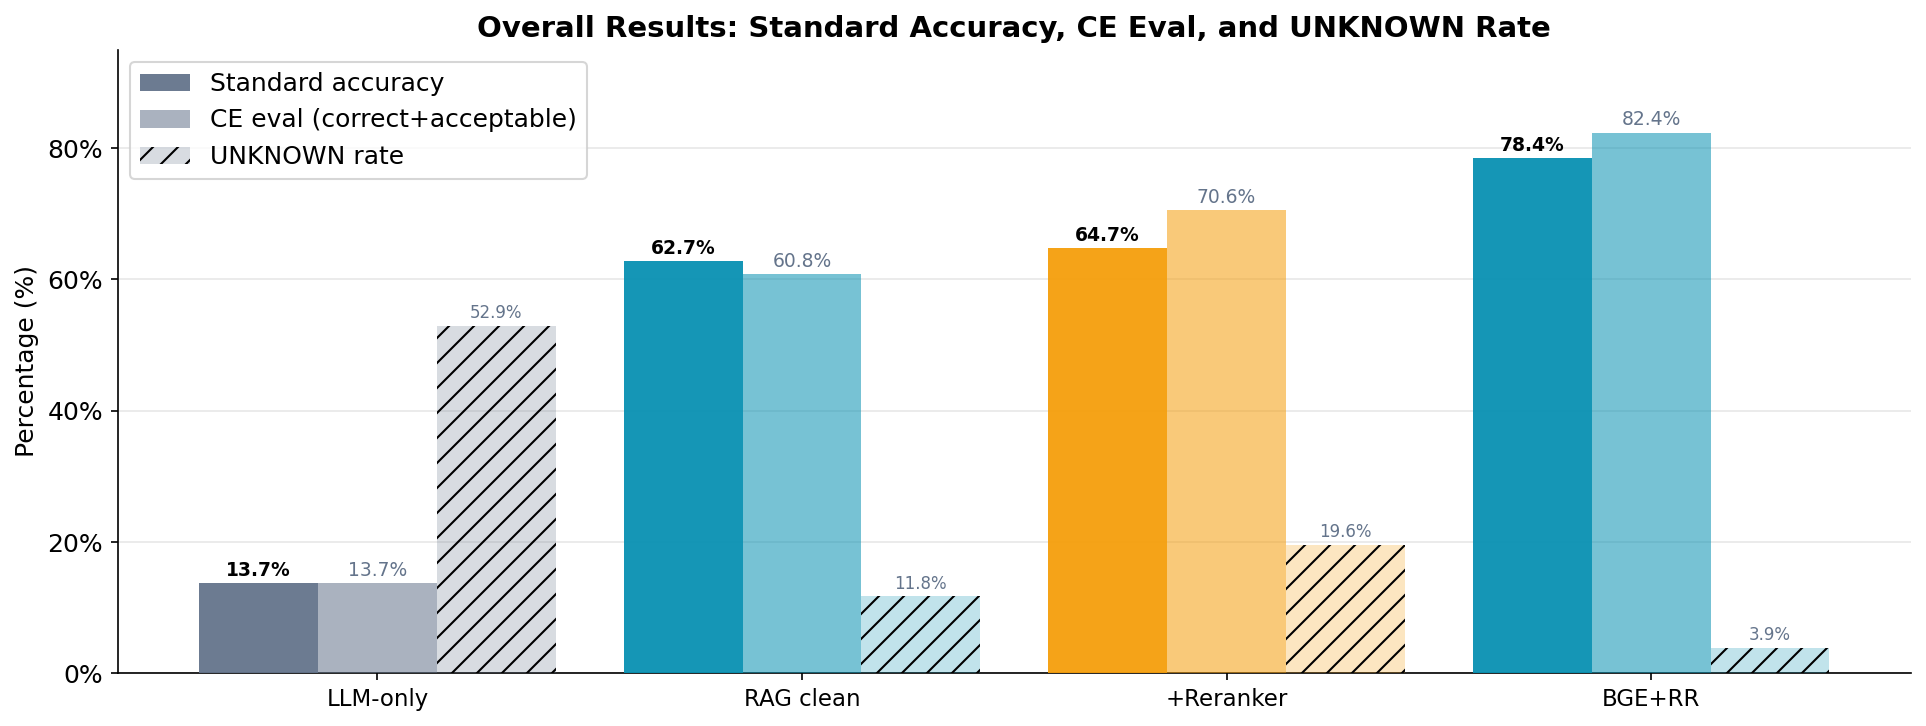

✓ fig1_overall_accuracy.png


In [26]:
# ── Figure 1: Overall accuracy + UNKNOWN rate bar chart ──────────────────────
summary = []
for cfg, col in zip(available, [CONFIG_COLORS[CONFIG_ORDER.index(c)] for c in available]):
    df_c = dfs[cfg]
    unk  = df_c['unknown'].mean() if 'unknown' in df_c.columns else (df_c['predicted'] == 'UNKNOWN').mean()
    summary.append({'config': cfg, 'color': col,
                    'std': df_c['correct_standard'].mean() * 100,
                    'ce':  (df_c['judgment'].isin(['correct','acceptable'])).mean() * 100,
                    'unk': unk * 100})
sum_df = pd.DataFrame(summary)
short  = [c.split(': ')[1] if ': ' in c else c for c in sum_df['config']]

x = np.arange(len(sum_df)); w = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w, sum_df['std'], w, color=sum_df['color'], alpha=0.95, label='Standard accuracy', zorder=3)
b2 = ax.bar(x,     sum_df['ce'],  w, color=sum_df['color'], alpha=0.55, label='CE eval (correct+acceptable)', zorder=3)
b3 = ax.bar(x + w, sum_df['unk'], w, color=sum_df['color'], alpha=0.25, hatch='//', label='UNKNOWN rate', zorder=3)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color=GREY)
for bar in b3:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, color=GREY)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=11)
ax.set_ylabel('Percentage (%)')
ax.set_title('Overall Results: Standard Accuracy, CE Eval, and UNKNOWN Rate')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_overall_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig1_overall_accuracy.png')

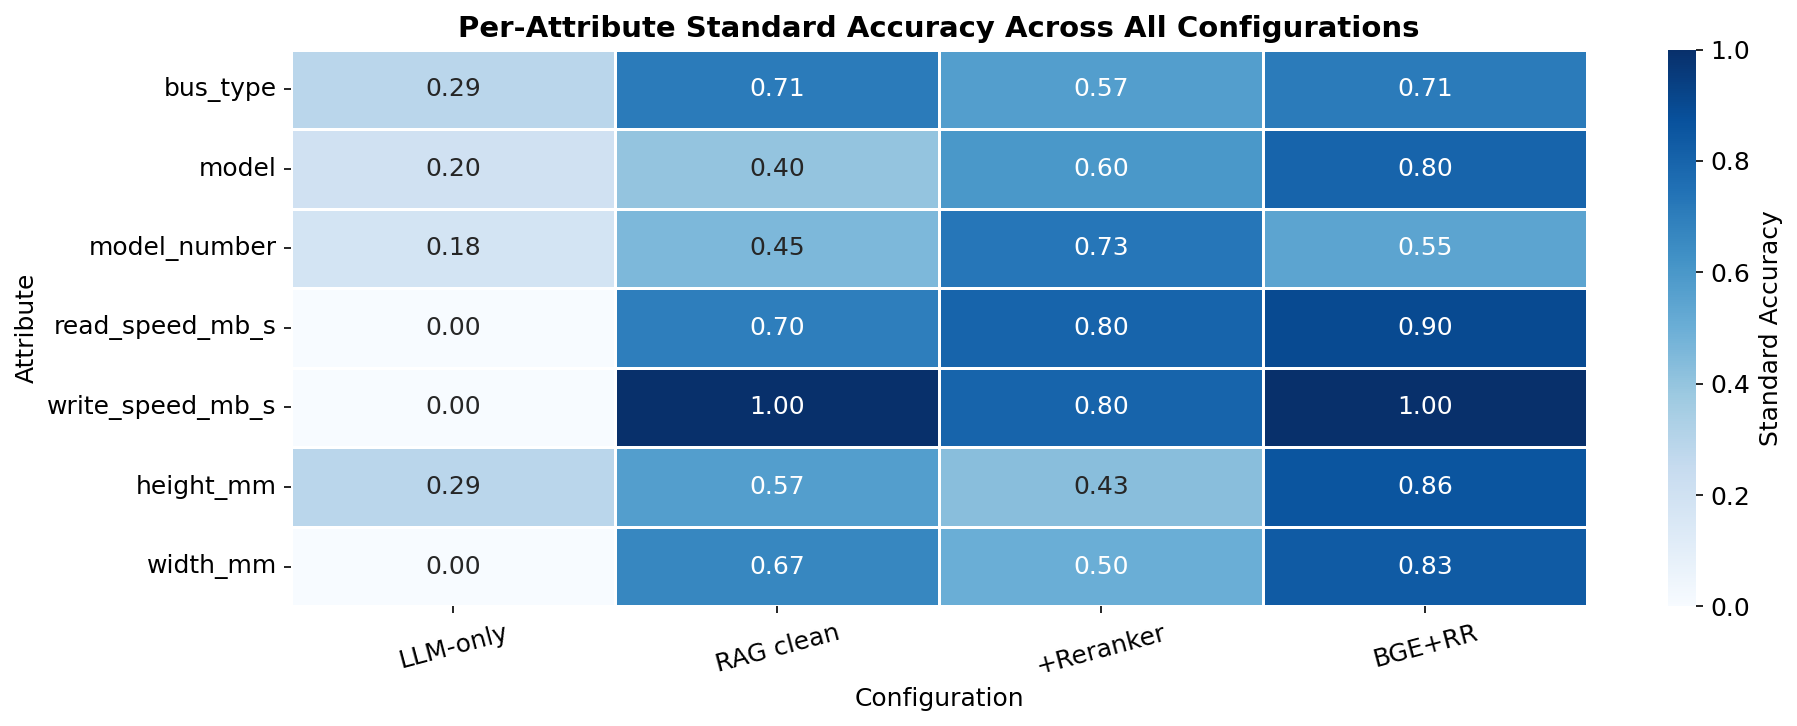

✓ fig2_heatmap_standard.png


In [27]:
# ── Figure 2: Per-attribute heatmap (standard accuracy) ──────────────────────
col_labels = {c: c.split(': ')[1] if ': ' in c else c for c in available}
hm = pivot.copy()
hm.columns = [col_labels[c] for c in hm.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Standard Accuracy'})
ax.set_title('Per-Attribute Standard Accuracy Across All Configurations')
ax.set_xlabel('Configuration')
ax.set_ylabel('Attribute')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_heatmap_standard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig2_heatmap_standard.png')

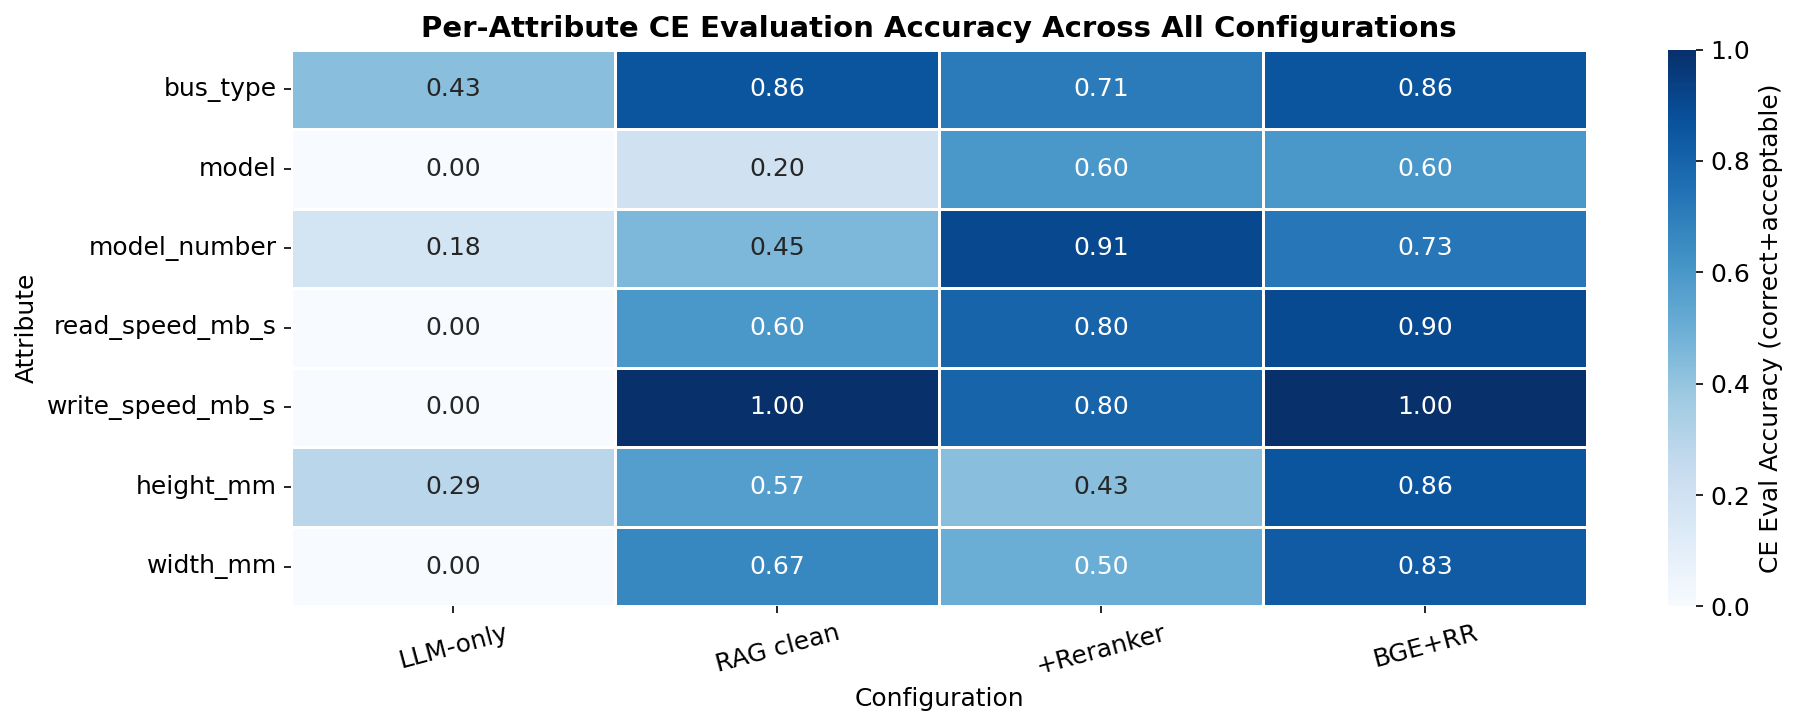

✓ fig3_heatmap_ce.png


In [28]:
# ── Figure 3: Per-attribute heatmap (CE eval) ─────────────────────────────────
hm_ce = pivot_ce.copy()
hm_ce.columns = [col_labels[c] for c in hm_ce.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(hm_ce, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'CE Eval Accuracy (correct+acceptable)'})
ax.set_title('Per-Attribute CE Evaluation Accuracy Across All Configurations')
ax.set_xlabel('Configuration')
ax.set_ylabel('Attribute')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_heatmap_ce.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig3_heatmap_ce.png')

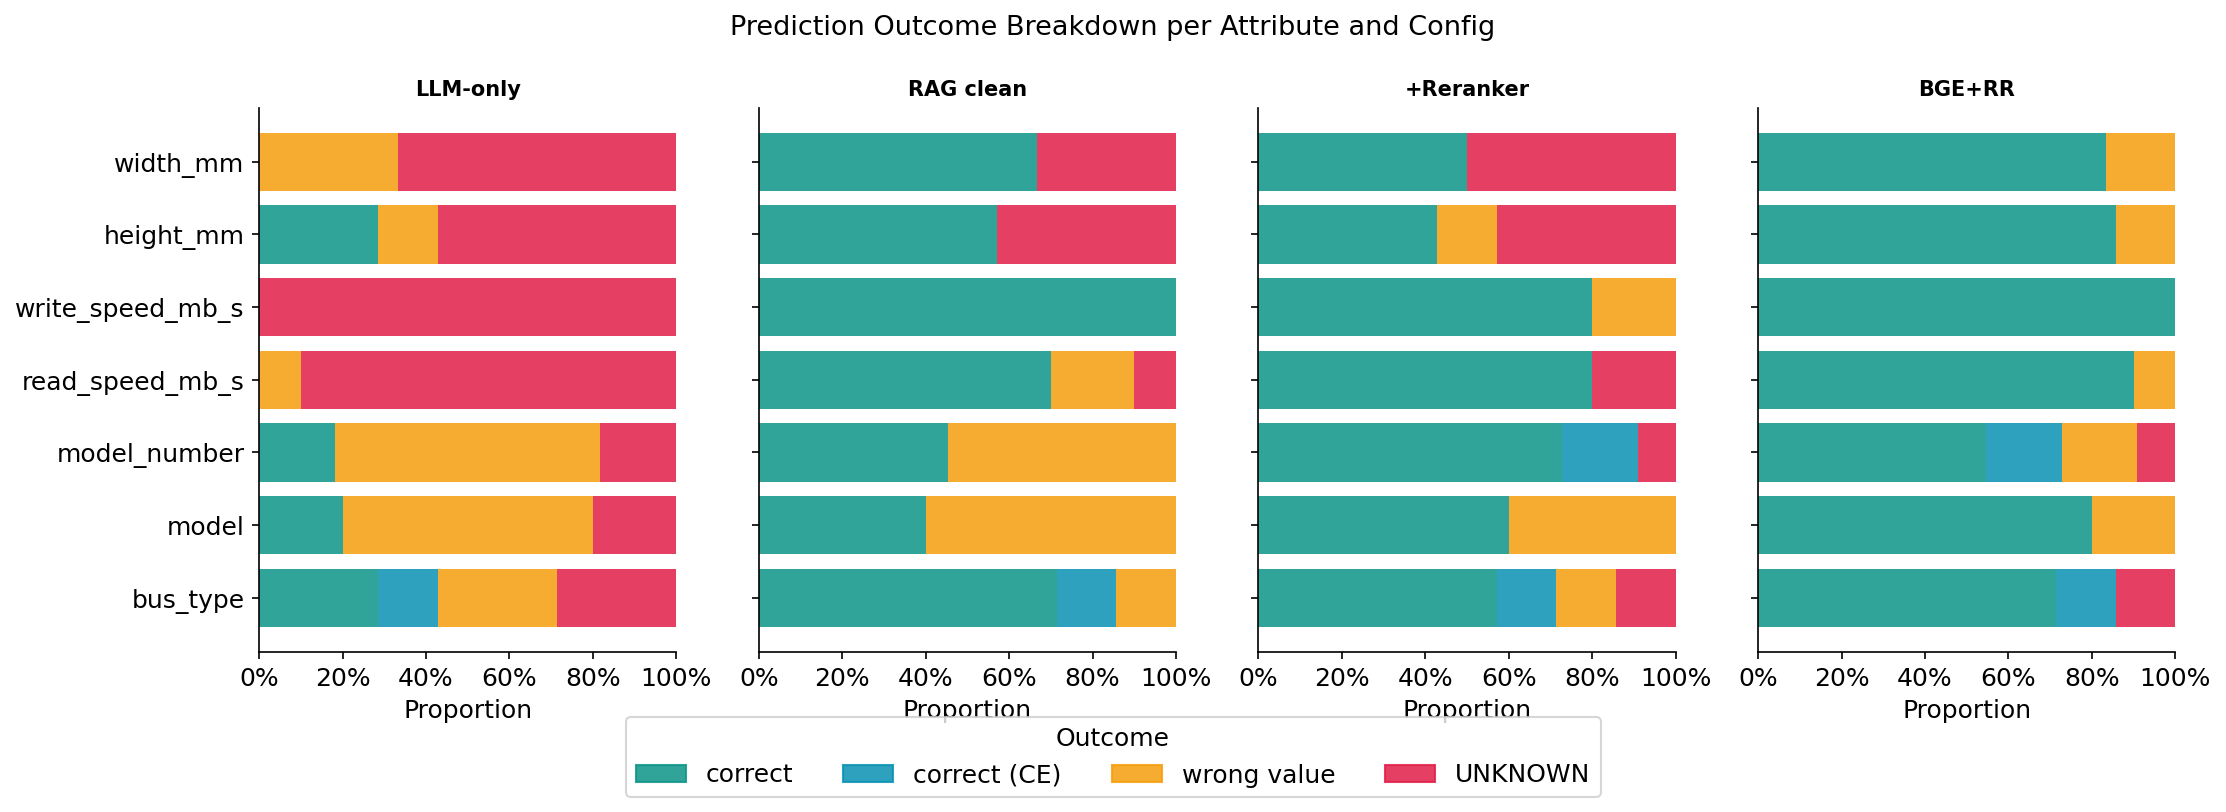

✓ fig4_outcome_breakdown.png


In [29]:
# ── Figure 4: Outcome breakdown stacked bar per config ───────────────────────
outcome_order  = ['correct', 'correct (CE)', 'wrong value', 'UNKNOWN']
outcome_colors = [GREEN, TEAL, GOLD, RED]

fig, axes = plt.subplots(1, len(available), figsize=(15, 5), sharey=True)
if len(available) == 1:
    axes = [axes]

for i, cfg in enumerate(available):
    ax   = axes[i]
    df_c = all_results[all_results['config'] == cfg]
    grp  = df_c.groupby(['attribute', 'outcome']).size().unstack(fill_value=0)
    for o in outcome_order:
        if o not in grp.columns:
            grp[o] = 0
    grp = grp.reindex(index=ATTR_ORDER, fill_value=0)[outcome_order]
    grp_pct = grp.div(grp.sum(axis=1), axis=0).fillna(0).astype(float)

    bottom = np.zeros(len(grp_pct))
    for j, (outcome, color) in enumerate(zip(outcome_order, outcome_colors)):
        vals = grp_pct[outcome].values
        ax.barh(range(len(grp_pct)), vals, left=bottom, color=color,
                label=outcome if i == 0 else '', alpha=0.85)
        bottom += vals

    ax.set_title(cfg.split(': ')[1] if ': ' in cfg else cfg, fontsize=10)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_xlabel('Proportion')
    if i == 0:
        ax.set_yticks(range(len(ATTR_ORDER)))
        ax.set_yticklabels(ATTR_ORDER)

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85) for c in outcome_colors]
fig.legend(handles, outcome_order, title='Outcome',
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Prediction Outcome Breakdown per Attribute and Config', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_outcome_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig4_outcome_breakdown.png')

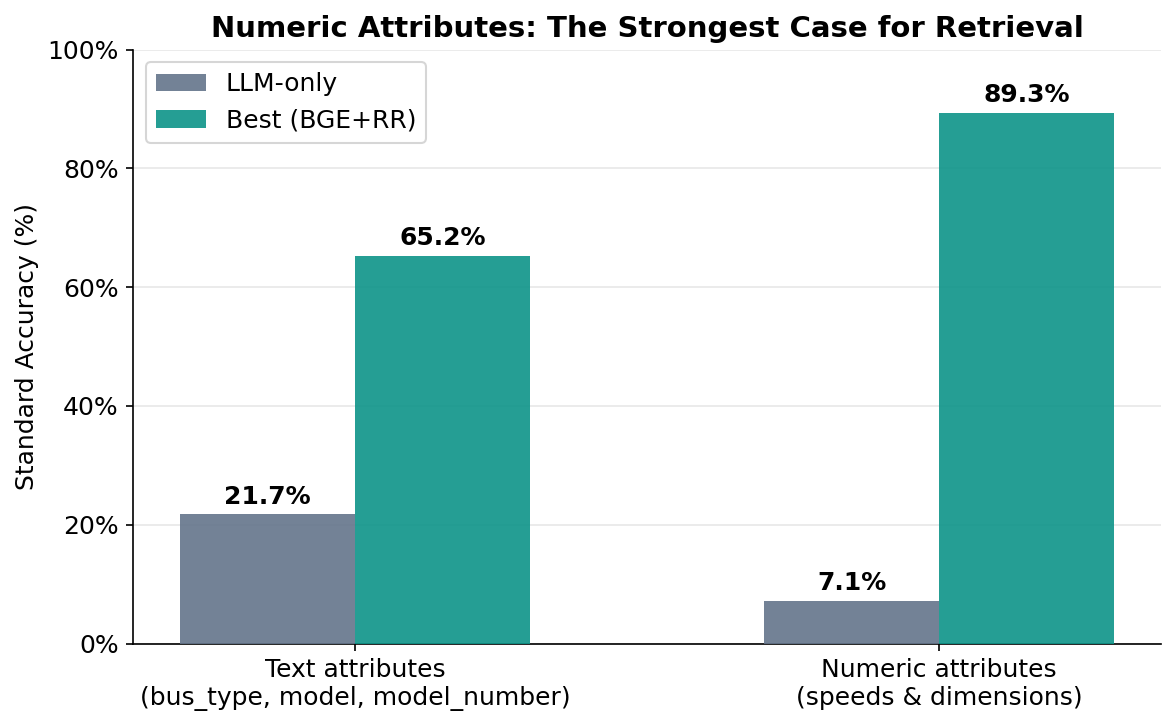

✓ fig5_numeric_vs_text.png


In [30]:
# ── Figure 5: Numeric vs text attributes comparison ──────────────────────────
NUM_ATTRS  = list(NUMERIC_ATTRIBUTES)
TEXT_ATTRS = list(TEXT_ATTRIBUTES)

def grp_acc(cfg, attrs):
    df_c = dfs[cfg]
    return df_c[df_c['attribute'].isin(attrs)]['correct_standard'].mean() * 100

best_cfg  = available[-1]
cats      = ['Text attributes\n(bus_type, model, model_number)',
             'Numeric attributes\n(speeds & dimensions)']
llm_vals  = [grp_acc(available[0], TEXT_ATTRS), grp_acc(available[0], NUM_ATTRS)]
best_vals = [grp_acc(best_cfg, TEXT_ATTRS),     grp_acc(best_cfg, NUM_ATTRS)]

x = np.arange(2); w = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, llm_vals,  w, color=GREY,  alpha=0.9, label='LLM-only', zorder=3)
b2 = ax.bar(x + w/2, best_vals, w, color=GREEN, alpha=0.9,
            label=f'Best ({best_cfg.split(": ")[1]})', zorder=3)
for bar in b1 + b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=12)
ax.set_ylabel('Standard Accuracy (%)')
ax.set_title('Numeric Attributes: The Strongest Case for Retrieval')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_numeric_vs_text.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig5_numeric_vs_text.png')

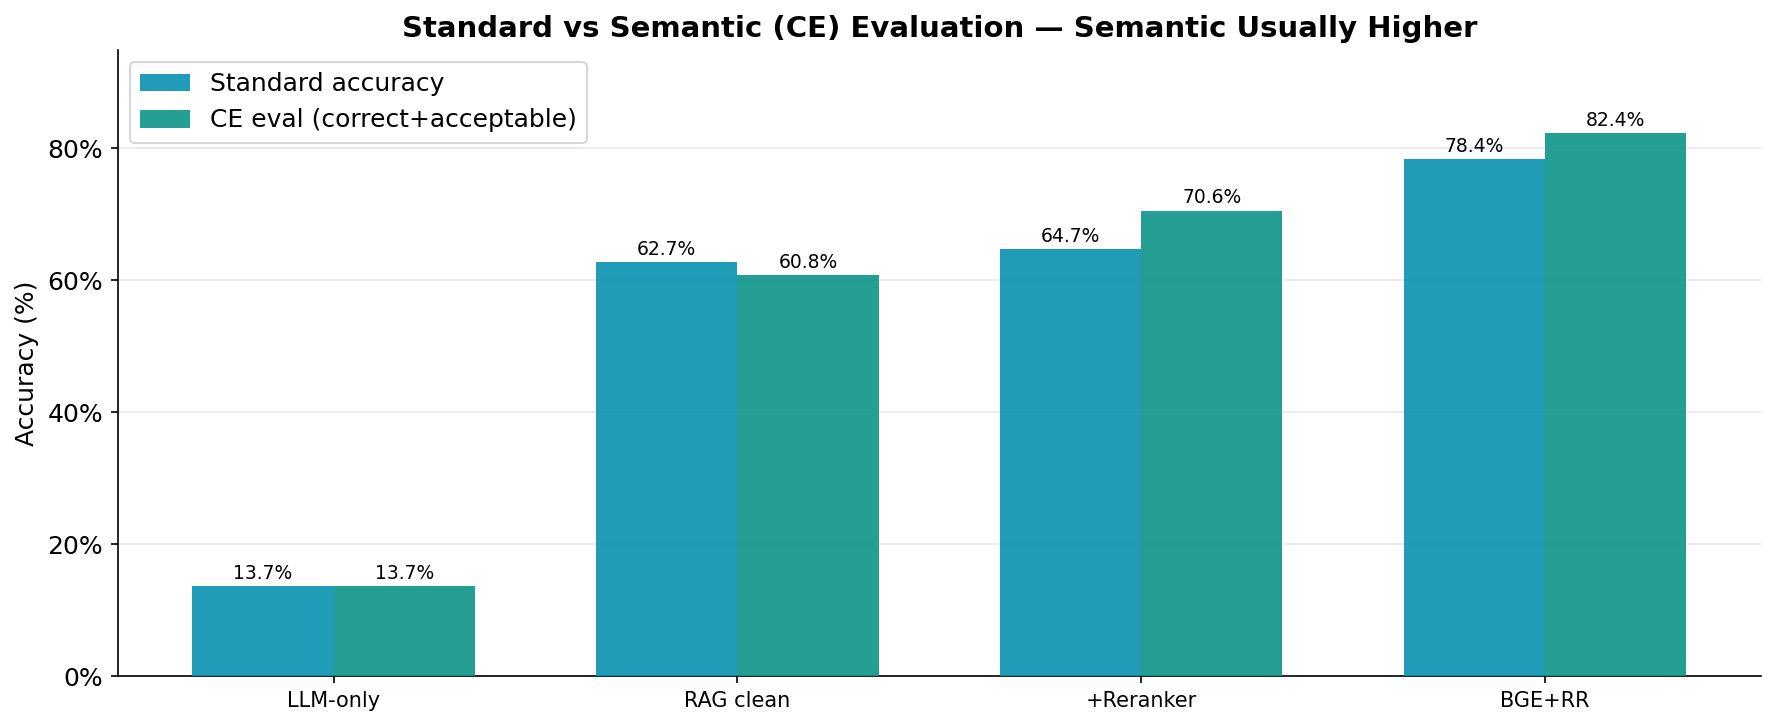

✓ fig6_standard_vs_ce.png


In [31]:
# ── Figure 6: Standard vs CE eval gap ────────────────────────────────────────
eval_rows = []
for cfg in available:
    df_c = dfs[cfg]
    eval_rows.append({
        'config':   cfg,
        'standard': df_c['correct_standard'].mean() * 100,
        'ce':       (df_c['judgment'].isin(['correct','acceptable'])).mean() * 100
    })
eval_df = pd.DataFrame(eval_rows)
short   = [c.split(': ')[1] if ': ' in c else c for c in eval_df['config']]

x = np.arange(len(eval_df)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, eval_df['standard'], w, color=TEAL,  alpha=0.9, label='Standard accuracy', zorder=3)
b2 = ax.bar(x + w/2, eval_df['ce'],       w, color=GREEN, alpha=0.9, label='CE eval (correct+acceptable)', zorder=3)
for bar in b1 + b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Standard vs Semantic (CE) Evaluation — Semantic Usually Higher')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_standard_vs_ce.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig6_standard_vs_ce.png')

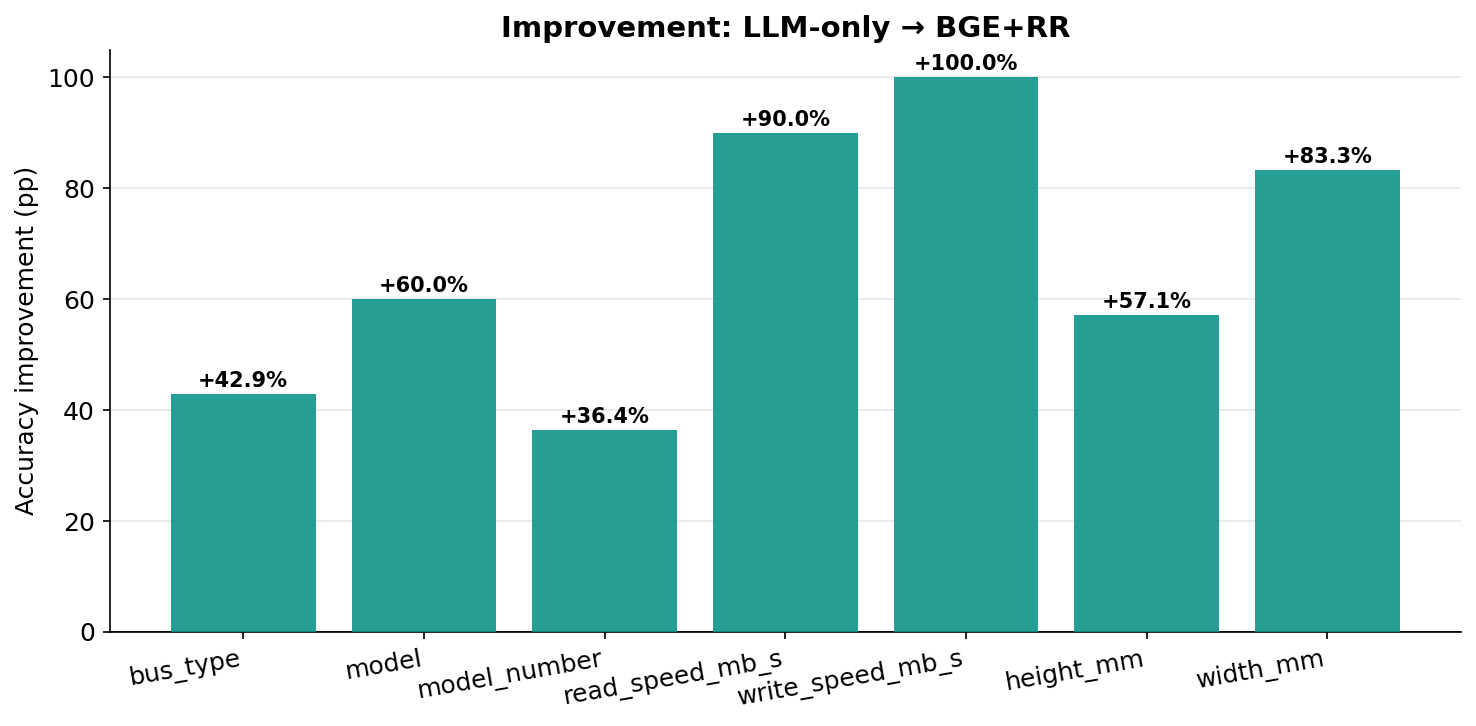

✓ fig7_improvement.png


In [32]:
# ── Figure 7: Per-attribute improvement — LLM-only vs BGE+RR ─────────────────
if available[0] in dfs and available[-1] in dfs:
    llm_acc = pivot[available[0]] * 100
    bge_acc = pivot[available[-1]] * 100
    improvement = bge_acc - llm_acc

    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = [GREEN if v >= 0 else RED for v in improvement.values]
    bars    = ax.bar(range(len(ATTR_ORDER)), improvement.reindex(ATTR_ORDER).values,
                     color=colors, alpha=0.9, zorder=3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,
                h + 0.5 if h >= 0 else h - 2,
                f'{h:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(ATTR_ORDER)))
    ax.set_xticklabels(ATTR_ORDER, rotation=10, ha='right')
    ax.set_ylabel('Accuracy improvement (pp)')
    ax.set_title(f'Improvement: LLM-only → {available[-1].split(": ")[1]}')
    ax.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/fig7_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ fig7_improvement.png')

## 10. Summary

In [33]:
print('=' * 60)
print('OUTPUT FILES')
print('=' * 60)
print('\nCSV / Excel:')
print('  side_by_side_comparison.csv  — all predictions in one table')
print('  side_by_side_comparison.xlsx — same, Excel format')
print(f'\nFigures saved to {FIGURES_DIR}/')
for f in sorted(os.listdir(FIGURES_DIR)):
    if f.endswith('.png'):
        print(f'  {f}')

OUTPUT FILES

CSV / Excel:
  side_by_side_comparison.csv  — all predictions in one table
  side_by_side_comparison.xlsx — same, Excel format

Figures saved to analysis_figures/
  fig1_overall_accuracy.png
  fig2_heatmap_standard.png
  fig3_heatmap_ce.png
  fig4_outcome_breakdown.png
  fig5_numeric_vs_text.png
  fig6_standard_vs_ce.png
  fig7_improvement.png
